<a href="https://colab.research.google.com/github/naa2412/CVL_Assignment04/blob/main/CVL_Assignment04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Computer Vision — Implementasi & Analisis Visual Tracking
**Nama:** Azhar Maulana  
**NIM:** 24/533487/PA/22582  
**Mata Kuliah:** Computer Vision  


## Deskripsi Tugas
Pada tugas ini, diimplementasikan dua metode *Visual Object Tracking* secara manual menggunakan NumPy tanpa menggunakan fungsi tracking bawaan OpenCV, yaitu:
1. **Template-Based Tracking** — menggunakan *Normalized Cross-Correlation* (NCC) dengan sliding window dan adaptive template update
2. **Optical Flow-Based Tracking** — menggunakan algoritma *Lucas-Kanade* dengan deteksi keypoint *Shi-Tomasi*

## Tujuan Eksperimen
Eksperimen ini bertujuan untuk membandingkan performa kedua metode tracking pada dua sequence video dengan karakteristik yang berbeda:
- **Sequence Bolt** — objek bergerak dengan displacement besar antar frame, banyak distractor di background, dan kamera yang mengikuti objek
- **Sequence Girl** — objek bergerak dengan displacement kecil antar frame, background statis, dan pencahayaan yang konsisten

Perbandingan dilakukan secara kuantitatif menggunakan metrik **IoU**, **Center Error**, **RMSE**, **Drift**, dan **FPS**, serta secara kualitatif melalui visualisasi hasil tracking pada frame sample dan video.

## Import & Install Library

In [ ]:
!pip install -q opencv-python-headless imageio[ffmpeg] requests

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import os, time, urllib.request

print('OpenCV version:', cv2.__version__)
print('NumPy version :', np.__version__)
print('Semua library siap!')


OpenCV version: 4.13.0
NumPy version : 2.0.2
Semua library siap!


## Download Dataset
Pada tahap ini, dataset video beserta file anotasi *ground truth* diunduh langsung dari Google Drive ke dalam penyimpanan Google Colab menggunakan `gdown`.

Dataset yang digunakan berasal dari **OTB2015 (Object Tracking Benchmark)** \[Wu et al., 2013\]. Dataset ini dipilih karena menyediakan anotasi *bounding box* per frame yang akurat sehingga memungkinkan evaluasi kuantitatif menggunakan metrik IoU dan *Center Error*.

### Dua skenario yang digunakan:

| Sequence | Karakteristik |
|----------|---------------|
| **Bolt** | Atlet sprint, displacement besar antar frame, banyak distractor |
| **Girl** | Wajah perempuan, gerakan halus, background relatif statis |

### Struktur file per sequence:
- `video.mp4` — video rekaman objek target
- `groundtruth_rect.txt` — anotasi bounding box per frame dalam format `x, y, w, h` (koordinat sudut kiri atas, lebar, tinggi)

> **Catatan:** Video disimpan dalam format `.mp4` dan akan diekstrak menjadi frame individual pada tahap berikutnya.

In [ ]:
!pip install -q gdown
import gdown
import os

os.makedirs('/content/dataset/bolt', exist_ok=True)
os.makedirs('/content/dataset/girl', exist_ok=True)

dataset_files = {
    '/content/dataset/bolt/video.mp4' : '1_neb9yFnV1t9Lo4ETFdtMhS5tIZldQeV',
    '/content/dataset/bolt/groundtruth_rect.txt' : '1xRTvz-swJI_T9f8XSJ_71bM1GG6sMB4n',

    '/content/dataset/girl/video.mp4' : '1IXHXTq6CWiftrrc1_9GBGAu_YEBnxsqD',
    '/content/dataset/girl/groundtruth_rect.txt' : '1dnxvHZPbyXZEnCSIC0Iulsp4PmuM12Gt',
}

for path, file_id in dataset_files.items():
    if not os.path.exists(path):
        print(f'Mengunduh {os.path.basename(path)}...')
        gdown.download(id=file_id, output=path, quiet=False)

print('\n[INFO] Semua file dataset berhasil diunduh dan siap digunakan!')

Mengunduh video.mp4...


Downloading...
From: https://drive.google.com/uc?id=1_neb9yFnV1t9Lo4ETFdtMhS5tIZldQeV
To: /content/dataset/bolt/video.mp4
100%|██████████| 10.4M/10.4M [00:00<00:00, 56.6MB/s]


Mengunduh groundtruth_rect.txt...


Downloading...
From: https://drive.google.com/uc?id=1xRTvz-swJI_T9f8XSJ_71bM1GG6sMB4n
To: /content/dataset/bolt/groundtruth_rect.txt
100%|██████████| 4.82k/4.82k [00:00<00:00, 6.21MB/s]


Mengunduh video.mp4...


Downloading...
From: https://drive.google.com/uc?id=1IXHXTq6CWiftrrc1_9GBGAu_YEBnxsqD
To: /content/dataset/girl/video.mp4
100%|██████████| 1.10M/1.10M [00:00<00:00, 109MB/s]


Mengunduh groundtruth_rect.txt...


Downloading...
From: https://drive.google.com/uc?id=1dnxvHZPbyXZEnCSIC0Iulsp4PmuM12Gt
To: /content/dataset/girl/groundtruth_rect.txt
100%|██████████| 6.49k/6.49k [00:00<00:00, 15.8MB/s]


[INFO] Semua file dataset berhasil diunduh dan siap digunakan!


## Ekstraksi Frame dari Video

Setelah video berhasil diunduh, tahap selanjutnya adalah mengekstrak setiap frame dari file `.mp4` menggunakan `cv2.VideoCapture`.

Frame disimpan dalam format BGR (format default OpenCV) tanpa konversi ke grayscale terlebih dahulu. Konversi ke grayscale dilakukan di dalam masing-masing fungsi tracker, bukan di tahap preprocessing. Hal ini bertujuan agar frame asli tetap tersedia untuk keperluan visualisasi hasil tracking(menampilkan bounding box berwarna di atas frame).

### Parameter ekstraksi:
- **Format output**: BGR (3 channel)
- **Jumlah frame**: 50 frame pertama dari masing-masing sequence
- **Ground truth**: dibaca dari file `.txt` dan dikonversi ke format `(x, y, w, h)`

> **Catatan:** Pembatasan 50 frame dilakukan untuk efisiensi komputasi, mengingat Template Matching NCC memiliki kompleksitas $O(S^2 \cdot T^2)$ yang membutuhkan waktu komputasi cukup lama per frame.

In [ ]:
import cv2
import numpy as np

def muat_dataset_otb_mp4(video_path, gt_path, max_frames=50):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened() and len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret: break
        frames.append(frame)
    cap.release()

    kotak_gt = []
    with open(gt_path, 'r') as f:
        for baris in f:
            data = baris.replace(',', ' ').strip().split()
            if len(data) >= 4:
                kotak_gt.append([int(float(data[0])), int(float(data[1])),
                                 int(float(data[2])), int(float(data[3]))])

    min_len = min(len(frames), len(kotak_gt))
    return frames[:min_len], kotak_gt[:min_len]

print("[INFO] Memproses ekstraksi dataset ke dalam memori...")
frames_bolt, gt_bolt = muat_dataset_otb_mp4(
    '/content/dataset/bolt/video.mp4',
    '/content/dataset/bolt/groundtruth_rect.txt',
    max_frames=50
)
frames_girl, gt_girl = muat_dataset_otb_mp4(
    '/content/dataset/girl/video.mp4',
    '/content/dataset/girl/groundtruth_rect.txt',
    max_frames=50
)

print(f"Data Bolt berhasil diekstrak: {len(frames_bolt)} frame")
print(f"Data Girl berhasil diekstrak: {len(frames_girl)} frame")

[INFO] Memproses ekstraksi dataset ke dalam memori...
Data Bolt berhasil diekstrak: 50 frame
Data Girl berhasil diekstrak: 50 frame


## Preview Ground Truth

Sebelum menjalankan algoritma *tracking*, visualisasi ini memastikan bahwa *bounding box* sudah sesuai dengan posisi objek.

[INFO] Menampilkan grid preview untuk memastikan akurasi anotasi...


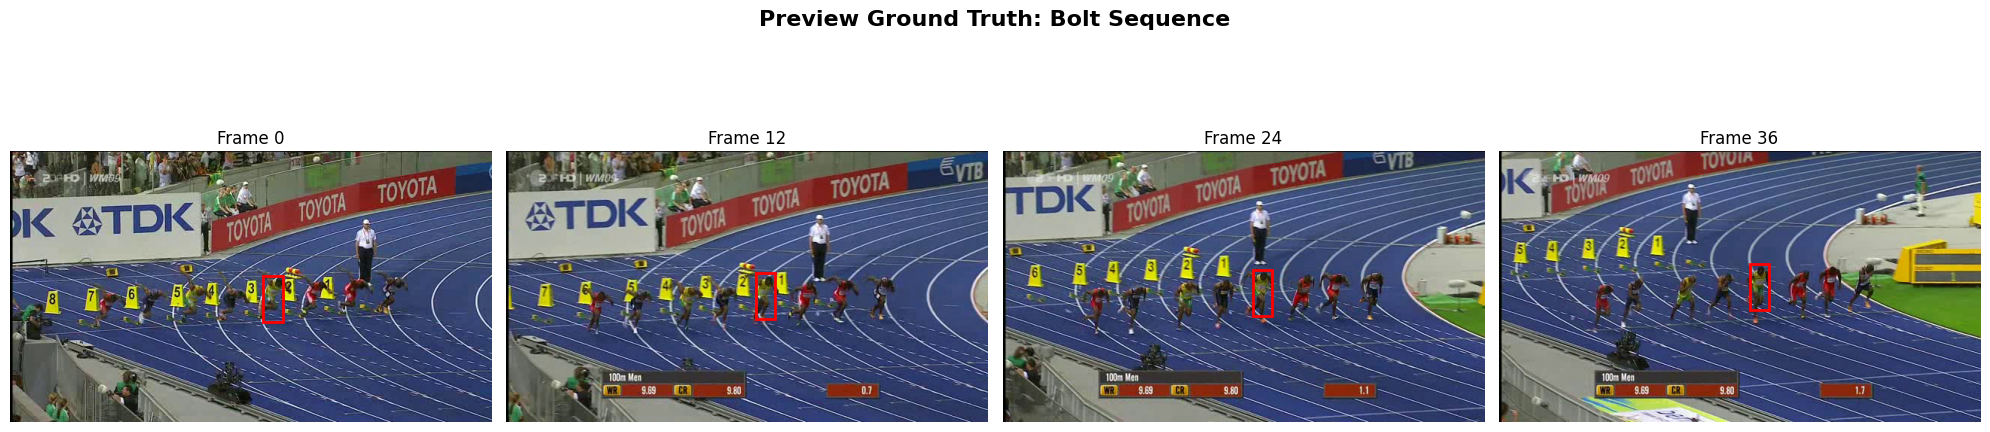

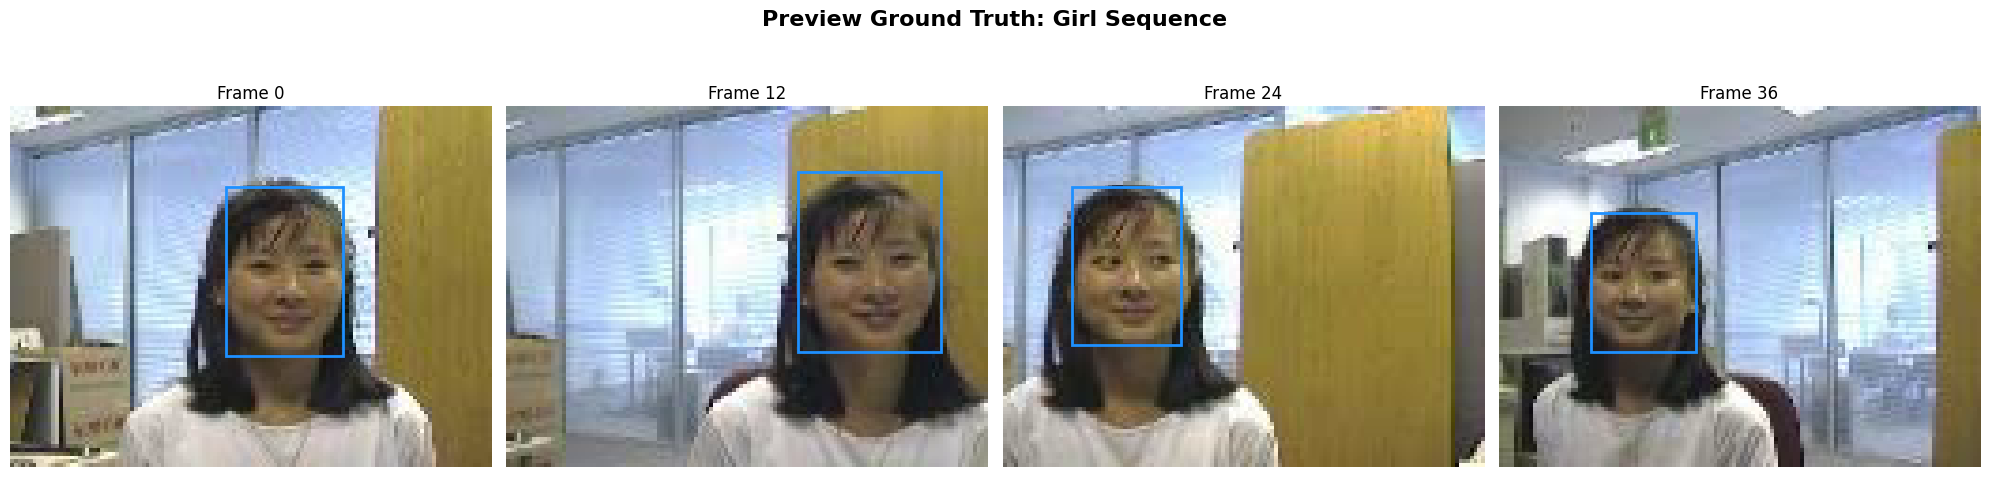

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def tampilkan_preview_grid(frames, gt_boxes, judul_video, warna_box='lime'):
    total_frame = len(frames)
    langkah = total_frame // 4
    indeks_sampel = [0, langkah, langkah * 2, langkah * 3]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"Preview Ground Truth: {judul_video}", fontsize=16, fontweight='bold', y=1.02)

    for i, ax in enumerate(axes):
        idx = indeks_sampel[i]
        ax.imshow(cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB))

        box = gt_boxes[idx]
        rect = patches.Rectangle((box[0], box[1]), box[2], box[3],
                                 linewidth=2, edgecolor=warna_box, facecolor='none')
        ax.add_patch(rect)

        ax.set_title(f"Frame {idx}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print("[INFO] Menampilkan grid preview untuk memastikan akurasi anotasi...")
tampilkan_preview_grid(frames_bolt, gt_bolt, "Bolt Sequence", warna_box='red')
tampilkan_preview_grid(frames_girl, gt_girl, "Girl Sequence", warna_box='dodgerblue')

## Implementasi Metode Tracking - Template Matching (NCC)

Normalized Cross-Correlation (NCC) mengukur kemiripan antara template $T$ (ukuran $M \times N$) dengan sub-image kandidat $\tilde{I}$ pada posisi $(i,j)$:

$$NCC(i,j) = \frac{1}{N \cdot M} \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} \frac{(I(i+m,j+n) - \bar{I}_{i,j}) \cdot (T(m,n) - \bar{T})}{\sigma_{I_{i,j}} \cdot \sigma_T}$$

- Nilai NCC ∈ [-1, 1], makin tinggi makin mirip  
- Posisi dengan NCC maksimum = lokasi objek  
- Template diperbarui tiap frame agar adaptif terhadap perubahan penampilan

In [ ]:
def ncc_score(patch: np.ndarray, template: np.ndarray) -> float:
    p = patch.astype(np.float64)
    t = template.astype(np.float64)
    p_std = p.std()
    t_std = t.std()
    if p_std < 1e-6 or t_std < 1e-6:
        return 0.0
    p_norm = (p - p.mean()) / p_std
    t_norm = (t - t.mean()) / t_std
    return float(np.mean(p_norm * t_norm))


def ncc_map(search_region: np.ndarray, template: np.ndarray) -> np.ndarray:
    th, tw = template.shape
    sh, sw = search_region.shape
    out_h  = sh - th + 1
    out_w  = sw - tw + 1

    if out_h <= 0 or out_w <= 0:
        return np.array([[0.0]])

    t_std = template.std()
    if t_std < 1e-6:
        return np.zeros((out_h, out_w))
    t_norm = (template - template.mean()) / t_std

    shape   = (out_h, out_w, th, tw)
    strides = (search_region.strides[0], search_region.strides[1],
               search_region.strides[0], search_region.strides[1])
    windows = np.lib.stride_tricks.as_strided(
        search_region, shape=shape, strides=strides
    )

    win_mean = windows.mean(axis=(2, 3), keepdims=True)
    win_std  = windows.std(axis=(2, 3), keepdims=True)
    win_std  = np.where(win_std < 1e-6, 1.0, win_std)
    win_norm = (windows - win_mean) / win_std

    score_map = (win_norm * t_norm).mean(axis=(2, 3))
    return score_map


def template_matching_ncc(
    frames        : list,
    init_bbox     : tuple,
    search_radius : int   = 40,
    update_alpha  : float = 0.10
) -> tuple:
    x, y, w, h = init_bbox
    H, W       = frames[0].shape[:2]

    # crop template dari frame pertama
    gray     = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY).astype(np.float64)
    template = gray[y:y+h, x:x+w]

    bboxes   = [init_bbox]
    scores   = [1.0]
    times_ms = [0.0]

    for i in range(1, len(frames)):
        t0   = time.perf_counter()
        gray = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY).astype(np.float64)

        sx = max(0, x - search_radius)
        sy = max(0, y - search_radius)
        ex = min(W, x + w + search_radius)
        ey = min(H, y + h + search_radius)
        region = gray[sy:ey, sx:ex]

        scores_map = ncc_map(region, template)

        best_idx   = np.unravel_index(np.argmax(scores_map), scores_map.shape)
        best_score = scores_map[best_idx]
        x = sx + best_idx[1]
        y = sy + best_idx[0]

        bboxes.append((x, y, w, h))
        scores.append(float(best_score))

        if update_alpha > 0 and best_score > 0.5:
            patch = gray[y:y+h, x:x+w]
            if patch.shape == template.shape:
                template = (1 - update_alpha) * template + update_alpha * patch

        times_ms.append((time.perf_counter() - t0) * 1000)

    return bboxes, scores, times_ms

print('Template Matching NCC siap!')

Template Matching NCC siap!


## Implementasi Metode Tracking - Lucas-Kanade Optical Flow

Lucas-Kanade mengasumsikan brightness constancy dan local motion:

$$I_x u + I_y v + I_t = 0$$

Untuk $n$ piksel dalam window $W$, susun sistem persamaan:

$$\mathbf{A} \mathbf{d} = \mathbf{b}$$

dengan $\mathbf{A} = [I_x, I_y]^T$, $\mathbf{b} = -I_t$

Solusi least-squares:

$$\begin{bmatrix} u \\ v \end{bmatrix} = (\mathbf{A}^T \mathbf{A})^{-1} \mathbf{A}^T \mathbf{b}$$

Syarat: $\mathbf{A}^T \mathbf{A}$ harus invertible (tekstur cukup, bukan flat region).

In [ ]:
def compute_gradients(frame: np.ndarray):
    """Hitung gradien spasial Ix dan Iy menggunakan central difference."""
    img = frame.astype(np.float64)

    Ix = np.zeros_like(img)
    Ix[:, 1:-1] = (img[:, 2:] - img[:, :-2]) / 2.0
    Ix[:,  0  ] =  img[:, 1]  - img[:, 0]
    Ix[:, -1  ] =  img[:, -1] - img[:, -2]

    Iy = np.zeros_like(img)
    Iy[1:-1, :] = (img[2:, :] - img[:-2, :]) / 2.0
    Iy[ 0,   :] =  img[1, :]  - img[0, :]
    Iy[-1,   :] =  img[-1, :] - img[-2, :]

    return Ix, Iy


def lk_flow_at_point(I1, I2, px, py, win_size=15):
    H, W = I1.shape
    hw   = win_size // 2
    r1 = max(0, py-hw);  r2 = min(H, py+hw+1)
    c1 = max(0, px-hw);  c2 = min(W, px+hw+1)
    p1 = I1[r1:r2, c1:c2].astype(np.float64)
    p2 = I2[r1:r2, c1:c2].astype(np.float64)
    if p1.size == 0:
        return 0.0, 0.0
    Ix, Iy = compute_gradients(p1)
    It     = p2 - p1
    ix = Ix.flatten()
    iy = Iy.flatten()
    it = It.flatten()
    AtA = np.array([[np.dot(ix,ix), np.dot(ix,iy)],
                     [np.dot(ix,iy), np.dot(iy,iy)]])
    Atb = np.array([-np.dot(ix,it), -np.dot(iy,it)])
    det = AtA[0,0]*AtA[1,1] - AtA[0,1]*AtA[1,0]
    if abs(det) < 1e-6:
        return 0.0, 0.0
    AtA_inv = np.array([[ AtA[1,1], -AtA[0,1]],
                         [-AtA[1,0],  AtA[0,0]]]) / det
    d = AtA_inv @ Atb
    return float(np.clip(d[0], -30.0, 30.0)), float(np.clip(d[1], -30.0, 30.0))


def detect_shi_tomasi(gray, bbox, max_corners=20,
                       quality=0.01, min_dist=7, block_size=5):
    x, y, w, h = [int(v) for v in bbox]
    H, W       = gray.shape
    region = gray[y:y+h, x:x+w].astype(np.float64)
    Ix, Iy = compute_gradients(region)
    Ixx = Ix ** 2
    Ixy = Ix * Iy
    Iyy = Iy ** 2
    k   = block_size if block_size % 2 == 1 else block_size + 1
    Sxx = cv2.GaussianBlur(Ixx, (k, k), 0)
    Sxy = cv2.GaussianBlur(Ixy, (k, k), 0)
    Syy = cv2.GaussianBlur(Iyy, (k, k), 0)
    trace  = Sxx + Syy
    det    = Sxx * Syy - Sxy ** 2
    disc   = np.maximum((trace / 2) ** 2 - det, 0)
    scores = trace / 2 - np.sqrt(disc)
    threshold = quality * scores.max()
    scores[scores < threshold] = 0
    corners    = []
    score_copy = scores.copy()
    for _ in range(max_corners):
        if score_copy.max() <= 0:
            break
        idx    = np.unravel_index(np.argmax(score_copy), score_copy.shape)
        ry, rx = idx
        corners.append([x + rx, y + ry])
        r0 = max(0, ry-min_dist);  r1 = min(h, ry+min_dist+1)
        c0 = max(0, rx-min_dist);  c1 = min(w, rx+min_dist+1)
        score_copy[r0:r1, c0:c1] = 0
    if len(corners) == 0:
        cx, cy = x + w//2, y + h//2
        corners = [[cx + int(dx), cy + int(dy)]
                   for dx in [-10, 0, 10]
                   for dy in [-10, 0, 10]
                   if 0 < cx+dx < W and 0 < cy+dy < H]
    return np.array(corners, dtype=np.float64)


def optical_flow_tracker(
    frames          : list,
    init_bbox       : tuple,
    win_size        : int = 15,
    max_corners     : int = 20,
    reinit_interval : int = 10
) -> tuple:
    x, y, w, h = init_bbox
    H, W       = frames[0].shape[:2]

    gray0     = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY).astype(np.float64)
    keypoints = detect_shi_tomasi(gray0, init_bbox,
                                   max_corners=max_corners,
                                   quality=0.01, min_dist=7)
    bboxes   = [init_bbox]
    scores   = [1.0]
    times_ms = [0.0]

    for i in range(1, len(frames)):
        t0 = time.perf_counter()

        I1 = cv2.cvtColor(frames[i-1], cv2.COLOR_BGR2GRAY).astype(np.float64)
        I2 = cv2.cvtColor(frames[i],   cv2.COLOR_BGR2GRAY).astype(np.float64)

        flows = []
        for kp in keypoints:
            px, py = int(round(kp[0])), int(round(kp[1]))
            if not (win_size < px < W-win_size and
                    win_size < py < H-win_size):
                continue
            u, v = lk_flow_at_point(I1, I2, px, py, win_size)
            if abs(u) + abs(v) < 1e-6:
                continue
            flows.append((u, v))

        if flows:
            flows = np.array(flows)
            med_u = float(np.median(flows[:, 0]))
            med_v = float(np.median(flows[:, 1]))
            score = len(flows) / max(len(keypoints), 1)
        else:
            med_u, med_v, score = 0.0, 0.0, 0.0

        x = int(np.clip(x + med_u, 0, W - w))
        y = int(np.clip(y + med_v, 0, H - h))
        bboxes.append((x, y, w, h))
        scores.append(score)

        keypoints[:, 0] = np.clip(keypoints[:, 0] + med_u, 0, W-1)
        keypoints[:, 1] = np.clip(keypoints[:, 1] + med_v, 0, H-1)

        if reinit_interval > 0 and i % reinit_interval == 0:
            gray_i    = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY).astype(np.float64)
            keypoints = detect_shi_tomasi(gray_i, (x, y, w, h),
                                           max_corners=max_corners,
                                           quality=0.01, min_dist=7)

        times_ms.append((time.perf_counter() - t0) * 1000)

    return bboxes, scores, times_ms

print('✅ Optical Flow Tracker (LK + Shi-Tomasi) siap!')

✅ Optical Flow Tracker (LK + Shi-Tomasi) siap!


## Fungsi Evaluasi

In [ ]:
def bboxes_to_centers(bboxes):
    """Konversi list of (x,y,w,h) → array (N,2) berisi (cx,cy)."""
    return np.array([[b[0]+b[2]/2, b[1]+b[3]/2] for b in bboxes])

def gt_to_centers(gt_bboxes):
    """Konversi ground truth (x,y,w,h) → array (N,2) berisi (cx,cy)."""
    return np.array([[g[0]+g[2]/2, g[1]+g[3]/2] for g in gt_bboxes])

def compute_iou(b1, b2):
    """Hitung IoU antara dua bbox (x,y,w,h)."""
    x1,y1,w1,h1 = b1
    x2,y2,w2,h2 = b2
    ix = max(0, min(x1+w1, x2+w2) - max(x1, x2))
    iy = max(0, min(y1+h1, y2+h2) - max(y1, y2))
    inter = ix * iy
    union = w1*h1 + w2*h2 - inter
    return inter / union if union > 0 else 0.0

def euclidean_errors(track, gt_centers):
    """Hitung Euclidean distance prediksi vs GT per frame."""
    n    = min(len(track), len(gt_centers))
    diff = track[:n] - gt_centers[:n]
    return np.sqrt((diff**2).sum(axis=1))

def compute_all_metrics(bboxes, gt_bboxes, times_ms, label=''):
    """
    Hitung semua metrik evaluasi:
    - IoU mean & std
    - Center Error mean & std
    - MAE, RMSE, Max Error
    - Drift (px/frame)
    - FPS
    """
    gt_centers = gt_to_centers(gt_bboxes)
    track      = bboxes_to_centers(bboxes)

    # IoU
    ious = np.array([compute_iou(p, g) for p, g in zip(bboxes, gt_bboxes)])

    # center error & turunannya
    errors = euclidean_errors(track, gt_centers)
    drift  = float(np.polyfit(np.arange(len(errors)), errors, 1)[0])

    # FPS
    avg_ms = np.mean(times_ms[1:])
    fps    = 1000 / avg_ms if avg_ms > 0 else 0

    print(f'\n [{label}]')
    print(f'   Mean IoU      : {ious.mean():.4f}  (std: {ious.std():.4f})')
    print(f'   Center Error  : {errors.mean():.2f} px  (std: {errors.std():.2f})')
    print(f'   RMSE          : {np.sqrt(np.mean(errors**2)):.2f} px')
    print(f'   Max Error     : {errors.max():.2f} px')
    print(f'   Drift         : {drift:+.3f} px/frame  '
          f'({"↑ menyimpang" if drift > 0.1 else "↓ stabil"})')

    return {
        'label'       : label,
        'iou_series'  : ious,
        'iou_mean'    : ious.mean(),
        'iou_std'     : ious.std(),
        'errors'      : errors,
        'err_mean'    : errors.mean(),
        'err_std'     : errors.std(),
        'rmse'        : float(np.sqrt(np.mean(errors**2))),
        'max_error'   : errors.max(),
        'drift'       : drift,
        'fps'         : fps,
    }


## Pengujian dan Evaluasi

In [ ]:
frames_fast = frames_bolt
gt_fast     = gt_bolt
frames_slow = frames_girl
gt_slow     = gt_girl

print(f'frames_fast: {len(frames_fast)} frames')
print(f'frames_slow: {len(frames_slow)} frames')

print('\n' + '='*50)
print('  SKENARIO 1: Sequence Bolt')
print('='*50)

print('\n[1/2] Template Matching NCC...')
tm_bboxes_fast, tm_scores_fast, tm_times_fast = template_matching_ncc(
    frames_fast, init_bbox=gt_fast[0], search_radius=60, update_alpha=0.10
)
print('[2/2] Optical Flow LK...')
of_bboxes_fast, of_scores_fast, of_times_fast = optical_flow_tracker(
    frames_fast, init_bbox=gt_fast[0], win_size=15, max_corners=20, reinit_interval=10
)
print(f'Selesai! TM: {np.mean(tm_times_fast[1:]):.1f}ms | OF: {np.mean(of_times_fast[1:]):.1f}ms')

print('\n' + '='*50)
print('  SKENARIO 2: Sequence Girl')
print('='*50)

print('\n[1/2] Template Matching NCC...')
tm_bboxes_slow, tm_scores_slow, tm_times_slow = template_matching_ncc(
    frames_slow, init_bbox=gt_slow[0], search_radius=30, update_alpha=0.10
)
print('[2/2] Optical Flow LK...')
of_bboxes_slow, of_scores_slow, of_times_slow = optical_flow_tracker(
    frames_slow, init_bbox=gt_slow[0], win_size=15, max_corners=20, reinit_interval=10
)
print(f'Selesai! TM: {np.mean(tm_times_slow[1:]):.1f}ms | OF: {np.mean(of_times_slow[1:]):.1f}ms')

print('\n' + '='*52)
print('  HASIL METRIK')
print('='*52)
m_tm_fast = compute_all_metrics(tm_bboxes_fast, gt_fast, tm_times_fast, 'Template Matching')
m_of_fast = compute_all_metrics(of_bboxes_fast, gt_fast, of_times_fast, 'Optical Flow LK')
m_tm_slow = compute_all_metrics(tm_bboxes_slow, gt_slow, tm_times_slow, 'Template Matching')
m_of_slow = compute_all_metrics(of_bboxes_slow, gt_slow, of_times_slow, 'Optical Flow LK')

frames_fast: 50 frames
frames_slow: 50 frames

  SKENARIO 1: Sequence Bolt

[1/2] Template Matching NCC...
[2/2] Optical Flow LK...
Selesai! TM: 456.8ms | OF: 2.7ms

  SKENARIO 2: Sequence Girl

[1/2] Template Matching NCC...
[2/2] Optical Flow LK...
Selesai! TM: 67.6ms | OF: 1.5ms

  HASIL METRIK

 [Template Matching]
   Mean IoU      : 0.0839  (std: 0.2255)
   Center Error  : 164.77 px  (std: 112.86)
   RMSE          : 199.71 px
   Max Error     : 339.74 px
   Drift         : +7.102 px/frame  (↑ menyimpang)

 [Optical Flow LK]
   Mean IoU      : 0.3354  (std: 0.2469)
   Center Error  : 15.96 px  (std: 8.58)
   RMSE          : 18.12 px
   Max Error     : 28.84 px
   Drift         : +0.587 px/frame  (↑ menyimpang)

 [Template Matching]
   Mean IoU      : 0.8269  (std: 0.0820)
   Center Error  : 1.63 px  (std: 1.59)
   RMSE          : 2.27 px
   Max Error     : 6.04 px
   Drift         : +0.063 px/frame  (↓ stabil)

 [Optical Flow LK]
   Mean IoU      : 0.2943  (std: 0.2268)
   Center E

## Visualisasi

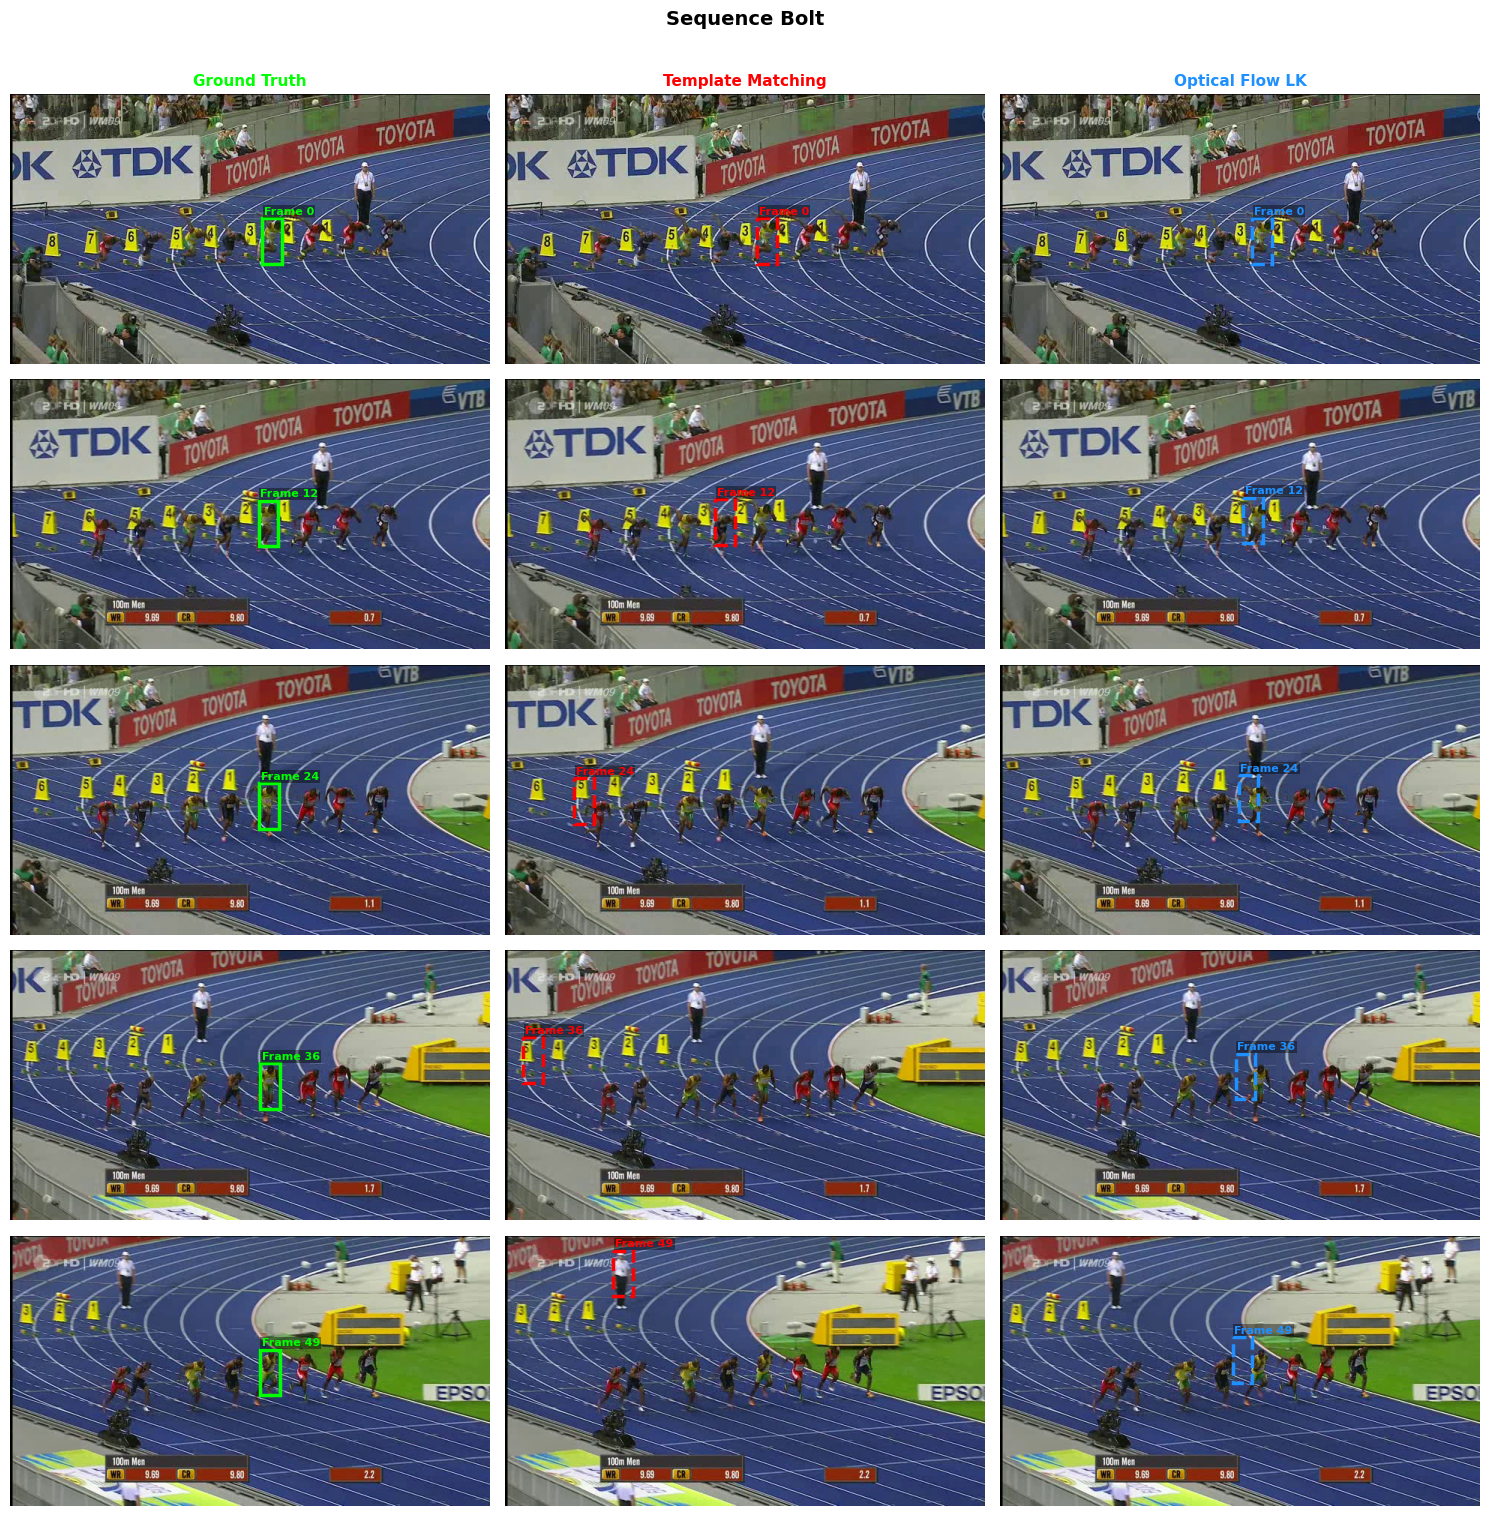

✅ Saved: /content/output/tracking_Sequence_Bolt.png


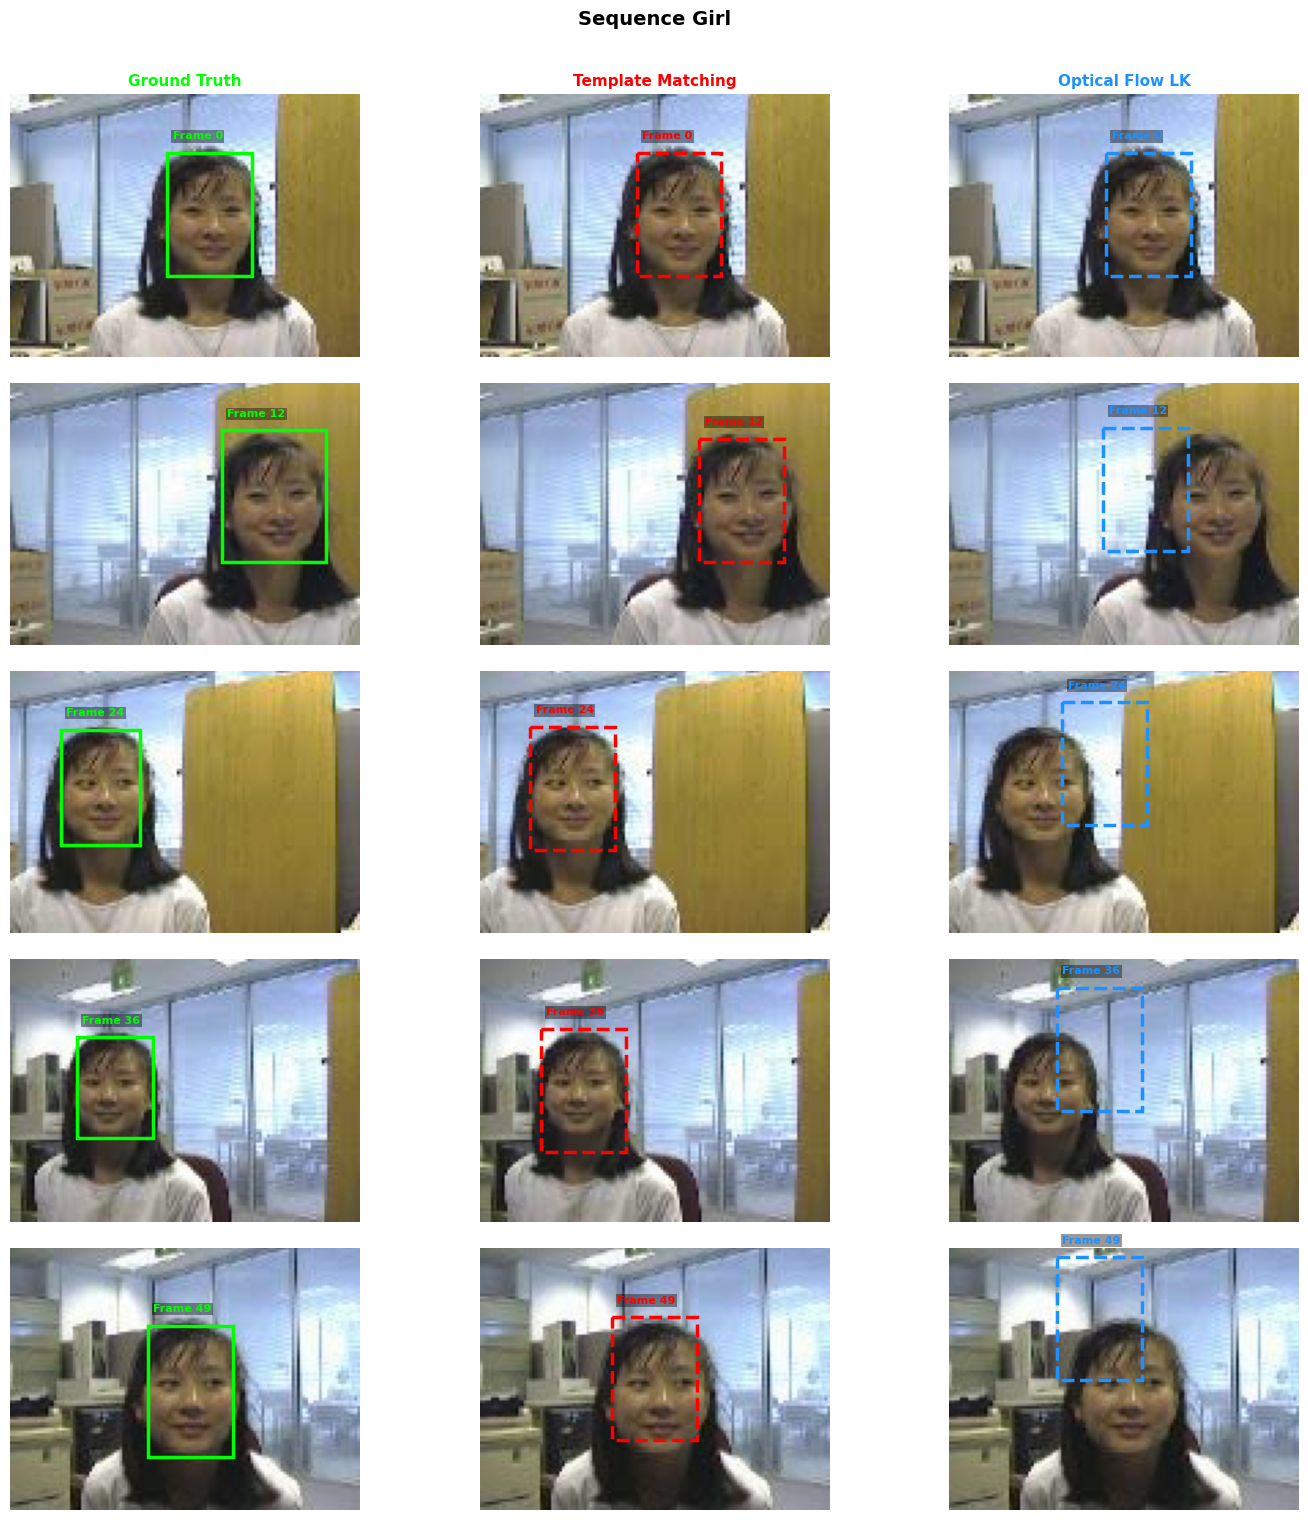

✅ Saved: /content/output/tracking_Sequence_Girl.png


In [ ]:
def visualize_tracking(frames, tm_bboxes, of_bboxes, gt_bboxes, title, n_samples=5):
    idxs = np.linspace(0, len(frames)-1, n_samples, dtype=int)
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 3*n_samples))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    cols = [('Ground Truth',      'lime'),
             ('Template Matching', 'red'),
             ('Optical Flow LK',   'dodgerblue')]

    for ci, (label, color) in enumerate(cols):
        axes[0][ci].set_title(label, color=color, fontweight='bold', fontsize=11)

    for ri, fi in enumerate(idxs):
        rgb = cv2.cvtColor(frames[fi], cv2.COLOR_BGR2RGB)
        bbs = [gt_bboxes[fi], tm_bboxes[fi], of_bboxes[fi]]

        for ci, (bb, (_, color)) in enumerate(zip(bbs, cols)):
            ax = axes[ri][ci]
            ax.imshow(rgb)
            x, y, w, h = [int(v) for v in bb]
            ax.add_patch(patches.Rectangle(
                (x, y), w, h, lw=2.5,
                edgecolor=color, facecolor='none',
                linestyle='-' if ci == 0 else '--'
            ))
            ax.text(x+2, y-5, f'Frame {fi}', color=color,
                    fontsize=8, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))
            ax.axis('off')

        axes[ri][0].set_ylabel(f'Frame {fi}', fontsize=9, rotation=0,
                                labelpad=50, va='center')

    plt.tight_layout()
    fname = f"/content/output/tracking_{title.replace(' ', '_').replace('—','')}.png"
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {fname}')

os.makedirs('/content/output', exist_ok=True)
visualize_tracking(frames_fast, tm_bboxes_fast, of_bboxes_fast, gt_fast, 'Sequence Bolt')
visualize_tracking(frames_slow, tm_bboxes_slow, of_bboxes_slow, gt_slow, 'Sequence Girl')

In [ ]:
def buat_video_tracking(frames, tm_bboxes, of_bboxes, gt_bboxes,
                         output_path, fps=15):
    """
    Buat video hasil tracking dengan overlay bbox:
    - Hijau      : Ground Truth
    - Merah      : Template Matching NCC
    - Biru muda  : Optical Flow LK
    """
    H, W = frames[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

    for i, frame in enumerate(frames):
        vis = frame.copy()

        x, y, w, h = [int(v) for v in gt_bboxes[i]]
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(vis, 'GT', (x, max(y-6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)

        x, y, w, h = [int(v) for v in tm_bboxes[i]]
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 0, 255), 2)
        cv2.putText(vis, 'TM', (x, max(y-6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2)

        x, y, w, h = [int(v) for v in of_bboxes[i]]
        cv2.rectangle(vis, (x, y), (x+w, y+h), (255, 165, 0), 2)
        cv2.putText(vis, 'OF', (x, max(y-6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 165, 0), 2)

        cv2.rectangle(vis, (0, 0), (200, 75), (0, 0, 0), -1)
        cv2.putText(vis, f'Frame: {i:03d}', (8, 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(vis, 'GT',  (8, 38),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        cv2.putText(vis, 'Template Matching', (28, 38),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(vis, 'TM',  (8, 58),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
        cv2.putText(vis, 'Optical Flow LK', (28, 58),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        out.write(vis)

    out.release()
    size_mb = os.path.getsize(output_path) / (1024*1024)
    print(f'Saved: {output_path} ({size_mb:.1f} MB)')


os.makedirs('/content/output', exist_ok=True)

print('Generating video Bolt ...')
buat_video_tracking(
    frames_fast, tm_bboxes_fast, of_bboxes_fast, gt_fast,
    '/content/output/tracking_bolt.mp4', fps=15
)

print('Generating video Girl ...')
buat_video_tracking(
    frames_slow, tm_bboxes_slow, of_bboxes_slow, gt_slow,
    '/content/output/tracking_girl.mp4', fps=10
)



Generating video Bolt ...
Saved: /content/output/tracking_bolt.mp4 (1.7 MB)
Generating video Girl ...
Saved: /content/output/tracking_girl.mp4 (0.1 MB)


## Analisis Hasil Eksperimen

### Skenario 1 — Sequence Bolt

Pada sequence Bolt, Optical Flow LK menunjukkan performa yang lebih unggul dibandingkan Template Matching dengan Mean IoU sebesar 0.3354 dan Center Error 15.96 px, sedangkan Template Matching hanya mencapai IoU 0.0839 dengan Center Error 164.77 px.

Hasil ini dapat dijelaskan dari karakteristik video Bolt itu sendiri:

- **Displacement besar antar frame**: Objek berpindah puluhan piksel per frame sehingga objek keluar dari *search region* Template Matching. Optical Flow tidak bergantung pada *search region*, ia mengikuti arah gradien piksel sehingga lebih mampu menangani perpindahan besar.
- **Banyak objek serupa di background**: Terdapat banyak atlet lain dengan penampilan visual mirip. Template Matching rentan mencocokkan template dengan objek yang salah (*false match*), sedangkan Optical Flow melacak keypoints spesifik yang sudah dideteksi sebelumnya.
- **Gerakan kamera**: Kamera mengikuti objek sehingga background ikut bergerak. Kondisi ini justru membantu Optical Flow karena flow background dan foreground berbeda secara konsisten.

Drift yang tinggi pada Template Matching (+7.102 px/frame) mengonfirmasi bahwa tracker semakin menyimpang dari ground truth seiring waktu, yang merupakan ciri khas kegagalan *search region* tracking.

---

### Skenario 2 — Sequence Girl

Pada sequence Girl, **Template Matching NCC** justru menunjukkan performa yang sangat unggul dengan Mean IoU 0.8269 dan Center Error hanya 1.63 px — jauh melampaui ambang keberhasilan tracking (IoU > 0.5). Sebaliknya, Optical Flow LK hanya mencapai IoU 0.2943 dengan Center Error 19.70 px.

Hasil ini juga dapat dijelaskan dari karakteristik video Girl:

- **Displacement kecil antar frame**: Objek berpindah sangat sedikit per frame sehingga selalu berada dalam *search region* Template Matching. Kondisi ini adalah kondisi ideal untuk NCC karena template masih sangat relevan dengan penampilan objek di frame berikutnya.
- **Background statis dan bersih**: Tidak ada objek lain yang mirip dengan target sehingga Template Matching tidak terkecoh oleh *false match*.
- **Sinyal flow terlalu lemah**: Optical Flow mengandalkan gradien intensitas antar frame untuk mengestimasi pergerakan. Ketika displacement sangat kecil, sinyal flow mendekati nol dan mudah terdominasi oleh noise sensor kamera, menyebabkan estimasi flow tidak akurat.
- **Akumulasi drift**: Meskipun error per frame kecil, error Optical Flow terakumulasi seiring waktu (+0.445 px/frame) karena setiap estimasi flow tidak sempurna. Template Matching tidak mengalami masalah ini karena setiap frame dilakukan pencarian independen dari awal.

---

### Kesimpulan Analisis

Perbedaan performa kedua metode bukan semata-mata ditentukan oleh kecepatan gerak objek, melainkan oleh karakteristik video secara keseluruhan:

| Karakteristik Video | Template Matching NCC | Optical Flow LK |
|---|---|---|
| Displacement kecil antar frame | ✅ Unggul | ❌ Sinyal lemah, rentan noise |
| Displacement besar antar frame | ❌ Objek keluar search region | ✅ Tidak bergantung search region |
| Background bersih, sedikit distractor | ✅ NCC akurat | ✅ Keypoints stabil |
| Banyak objek serupa di background | ❌ False match | ✅ Melacak keypoints spesifik |
| Pencahayaan konsisten | ✅ Stabil | ✅ Brightness constancy terpenuhi |
| Kamera bergerak | ❌ Search region bergeser | ⚠️ Tergantung besar gerakan kamera |

Dengan demikian, pemilihan metode tracking yang tepat harus mempertimbangkan karakteristik video target, bukan hanya kecepatan gerak objeknya.

### Analisis Per Metrik

#### 1. Mean IoU (Intersection over Union)

IoU mengukur seberapa besar tumpang tindih antara bounding box prediksi dan ground truth. Nilai IoU = 1.0 berarti prediksi sempurna, sedangkan IoU = 0 berarti tidak ada tumpang tindih sama sekali. Ambang batas keberhasilan tracking yang umum digunakan adalah IoU > 0.5.

| Metode | Bolt | Girl |
|--------|------|------|
| Template Matching NCC | 0.0839 ❌ | 0.8269 ✅ |
| Optical Flow LK | 0.3354 ⚠️ | 0.2943 ❌ |

Pada sequence Bolt, kedua metode menghasilkan IoU di bawah 0.5, namun Optical Flow LK tetap lebih unggul dengan selisih signifikan (0.3354 vs 0.0839). Hal ini menunjukkan bahwa meskipun kedua metode kesulitan melacak objek yang berpindah dengan cepat, Optical Flow masih mampu mempertahankan posisi yang lebih dekat dengan ground truth.

Pada sequence Girl, Template Matching mencapai IoU 0.8269 yang tergolong sangat baik, sementara Optical Flow hanya 0.2943. Ini mengonfirmasi bahwa ketika displacement kecil dan background bersih, Template Matching jauh lebih akurat dalam mempertahankan overlap dengan ground truth.

---

#### 2. Center Error & RMSE

Center Error mengukur jarak Euclidean antara pusat bounding box prediksi dengan pusat ground truth dalam satuan piksel. RMSE memberikan penalti lebih besar terhadap error yang ekstrem.

| Metode | CE Bolt | RMSE Bolt | CE Girl | RMSE Girl |
|--------|---------|-----------|---------|-----------|
| Template Matching NCC | 164.77 px | 199.71 px | **1.63 px** | **2.27 px** |
| Optical Flow LK | **15.96 px** | **18.12 px** | 19.70 px | 21.44 px |

Perbedaan Center Error pada sequence Bolt sangat mencolok — Template Matching meleset rata-rata 164.77 px per frame, hampir selebar frame itu sendiri. Ini mengindikasikan tracker telah kehilangan objek sejak awal dan tidak berhasil menemukannya kembali.

Sebaliknya, pada sequence Girl, Template Matching mencapai Center Error hanya 1.63 px — artinya prediksi pusat bbox rata-rata hanya meleset kurang dari 2 piksel dari ground truth. Ini adalah performa yang sangat presisi untuk tugas tracking.

---

#### 3. Max Error

Max Error mencerminkan kasus terburuk yang dialami tracker, seberapa jauh tracker bisa menyimpang dari ground truth pada satu frame tertentu.

| Metode | Max Error Bolt | Max Error Girl |
|--------|---------------|----------------|
| Template Matching NCC | 339.74 px | **6.04 px** |
| Optical Flow LK | **28.84 px** | 33.24 px |

Max Error Template Matching pada Bolt mencapai 339.74 px, hampir separuh lebar frame (640 px). Ini menunjukkan bahwa pada beberapa frame, tracker benar-benar kehilangan objek sepenuhnya dan memprediksi posisi yang jauh dari kenyataan.

Menariknya, pada sequence Girl, Max Error Template Matching hanya 6.04 px — bahkan dalam kondisi terburuk sekalipun, prediksinya masih sangat dekat dengan ground truth. Sebaliknya, Optical Flow memiliki Max Error 33.24 px pada Girl, menunjukkan bahwa akumulasi drift sesekali menghasilkan prediksi yang jauh menyimpang.

---

#### 4. Drift (px/frame)

Drift mengukur laju peningkatan error terhadap waktu menggunakan regresi linear. Nilai positif berarti error semakin membesar seiring berjalannya frame, nilai mendekati nol berarti tracker stabil.

| Metode | Drift Bolt | Drift Girl |
|--------|-----------|-----------|
| Template Matching NCC | +7.102 px/frame ↑ | **+0.063 px/frame ↓** |
| Optical Flow LK | **+0.587 px/frame ↑** | +0.445 px/frame ↑ |

Drift Template Matching pada Bolt sebesar +7.102 px/frame adalah yang tertinggi di antara semua kondisi. Artinya, setiap frame tracker semakin menyimpang 7 piksel dari ground truth — pada frame ke-50, total penyimpangan bisa mencapai lebih dari 350 piksel. Ini menggambarkan kegagalan sistematis, bukan sekadar error acak.

Sebaliknya, Template Matching pada Girl memiliki drift hanya +0.063 px/frame — praktis nol, menunjukkan tracker berhasil mengikuti objek secara konsisten sepanjang sequence tanpa akumulasi error yang berarti.

Optical Flow pada kedua skenario menunjukkan drift yang moderat. Pada Bolt (+0.587 px/frame), meskipun masih ada penyimpangan, jauh lebih kecil dibanding Template Matching. Pada Girl (+0.445 px/frame), drift Optical Flow justru lebih besar dari Template Matching, mengonfirmasi bahwa akumulasi error estimasi flow menjadi masalah ketika displacement sangat kecil.

---

#### 5. Kecepatan Komputasi (FPS)

| Metode | FPS Bolt | FPS Girl |
|--------|---------|---------|
| Template Matching NCC | 2.2 FPS | 15.1 FPS |
| Optical Flow LK | **372.2 FPS** | **1182.0 FPS** |

Optical Flow LK secara konsisten jauh lebih cepat pada kedua skenario. Perbedaan ini disebabkan oleh perbedaan fundamental kompleksitas komputasi:

- **Template Matching NCC** memiliki kompleksitas $O(S^2 \cdot T^2)$ di mana $S$ adalah ukuran search region dan $T$ adalah ukuran template. Setiap frame harus mengevaluasi ribuan posisi window secara menyeluruh.
- **Optical Flow LK** hanya menghitung flow di sejumlah kecil keypoints (20 keypoints), sehingga kompleksitasnya jauh lebih rendah dan konsisten.

Perbedaan FPS antara Bolt dan Girl pada Template Matching (2.2 vs 15.1 FPS) disebabkan oleh perbedaan ukuran search radius — Bolt menggunakan search_radius=60 sedangkan Girl menggunakan search_radius=30, sehingga area yang dipindai pada Bolt empat kali lebih besar.

Dari sisi aplikasi praktis, Optical Flow LK jauh lebih layak untuk digunakan dalam sistem real-time, sedangkan Template Matching NCC lebih sesuai untuk aplikasi offline yang mengutamakan akurasi di atas kecepatan.